## Hypothesis 3
Adding Gaussian noise to MNIST images will degrade the MLP’s classification performance, and the degradation will become larger as the noise intensity increases. The model was trained only on clean images and therefore learned relationships between specific normalized pixel patterns and digit labels. Gaussian noise changes those pixel values and can obscure important strokes or introduce misleading patterns. We consequently expect accuracy to decrease and cross-entropy loss to increase monotonically as the noise standard deviation rises. Because the original pixel values are scaled to \([0,1]\), I will test Gaussian noise levels of \(0.00, 0.05, 0.10, 0.20,\) and \(0.30\), clip the perturbed pixels back to \([0,1]\), and report mean ± sample standard deviation across the three saved models.

In [5]:
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from matplotlib.ticker import PercentFormatter

import scratch

importlib.reload(scratch)

from scratch import *

In [6]:
print("Loading MNIST data...")

train_dataset, test_dataset = load_mnist_data()

print("Preprocessing MNIST data...")

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = preprocess_data(
    train_dataset,
    test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)


print("\nData shapes")
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


assert X_train.shape == (50000, 784)
assert X_val.shape == (10000, 784)
assert X_test.shape == (10000, 784)

Loading MNIST data...
Preprocessing MNIST data...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0

Data shapes
Training: (50000, 784) (50000,)
Validation: (10000, 784) (10000,)
Test: (10000, 784) (10000,)


In [7]:
OH3_OUTPUT_DIR = Path(
    "output/hypotheses/h3_gaussian_noise"
)

OH3_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


OH3_MODEL_DIR = Path(
    "output/test_reports/checkpoints"
)


OH3_SEEDS = generate_experiment_seeds(
    base_seed=SPLIT_SEED,
    number_of_seeds=3
)


OH3_NOISE_LEVELS = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00
]


# Separate fixed noise patterns for validation and test.
OH3_VALIDATION_NOISE_SEED = (
    SPLIT_SEED + 3001
)

OH3_TEST_NOISE_SEED = (
    SPLIT_SEED + 3002
)


print("H3 output folder:", OH3_OUTPUT_DIR)
print("Saved-model folder:", OH3_MODEL_DIR)
print("Seeds:", OH3_SEEDS)
print("Gaussian noise levels:", OH3_NOISE_LEVELS)
print(
    "Validation noise seed:",
    OH3_VALIDATION_NOISE_SEED
)
print(
    "Test noise seed:",
    OH3_TEST_NOISE_SEED
)

H3 output folder: output/hypotheses/h3_gaussian_noise
Saved-model folder: output/test_reports/checkpoints
Seeds: [654571, 89250, 773955]
Gaussian noise levels: [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Validation noise seed: 3043
Test noise seed: 3044


In [8]:
oh3_models = {}
oh3_checkpoint_rows = []
intialization="small"

learning_rate = "0p1"

for seed in OH3_SEEDS:

    checkpoint_path = (
        OH3_MODEL_DIR
        / f"best_model_init-{intialization}_lr-{learning_rate}_seed-{seed}.pt"
    )

    assert checkpoint_path.exists(), (
        f"Checkpoint not found: "
        f"{checkpoint_path}"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True
    )

    parameters = {
        parameter_name: (
            parameter_tensor
            .cpu()
            .numpy()
            .copy()
        )
        for (
            parameter_name,
            parameter_tensor
        ) in checkpoint[
            "parameters"
        ].items()
    }

   
    oh3_models[seed] = {
        "parameters": parameters,
        "activation": checkpoint[
            "activation"
        ],
        "selected_epoch": checkpoint[
            "best_epoch"
        ],
        "checkpoint_path": str(
            checkpoint_path
        )
    }

    oh3_checkpoint_rows.append({
        "seed": seed,
        "selected_epoch": checkpoint[
            "best_epoch"
        ],
        "validation_accuracy": checkpoint[
            "best_val_accuracy"
        ],
        "validation_loss": checkpoint[
            "best_val_loss"
        ],
        "checkpoint_path": str(
            checkpoint_path
        )
    })


oh3_checkpoint_df = pd.DataFrame(
    oh3_checkpoint_rows
)

display(oh3_checkpoint_df)

,seed,selected_epoch,validation_accuracy,validation_loss,checkpoint_path
0,654571,75,0.9800,0.072569,output/test_reports/checkpoints/best_model_ini...
1,89250,68,0.9795,0.075936,output/test_reports/checkpoints/best_model_ini...
2,773955,80,0.9789,0.074269,output/test_reports/checkpoints/best_model_ini...


In [9]:
#gaussina noise function
def oh3_create_standard_noise(
    X,
    noise_seed
):
    noise_rng = np.random.default_rng(
        noise_seed
    )

    standard_noise = (
        noise_rng.standard_normal(
            size=X.shape
        )
        .astype(np.float32)
    )

    return standard_noise


def oh3_add_gaussian_noise(
    X,
    standard_noise,
    noise_std
):
    if noise_std < 0:
        raise ValueError(
            "noise_std cannot be negative."
        )

    if noise_std == 0:
        return X.copy()

    noisy_X = (
        X
        + noise_std * standard_noise
    )

    # Keep normalized pixel values within [0, 1].
    noisy_X = np.clip(
        noisy_X,
        0.0,
        1.0
    )

    return noisy_X

In [10]:
oh3_validation_standard_noise = (
    oh3_create_standard_noise(
        X_val,
        OH3_VALIDATION_NOISE_SEED
    )
)


print(
    "Validation noise shape:",
    oh3_validation_standard_noise.shape
)

print(
    "Noise mean:",
    oh3_validation_standard_noise.mean()
)

print(
    "Noise standard deviation:",
    oh3_validation_standard_noise.std()
)

Validation noise shape: (10000, 784)
Noise mean: 6.0010352e-05
Noise standard deviation: 1.000432


Saved: output/hypotheses/h3_gaussian_noise/h3_original_vs_noisy_examples.png


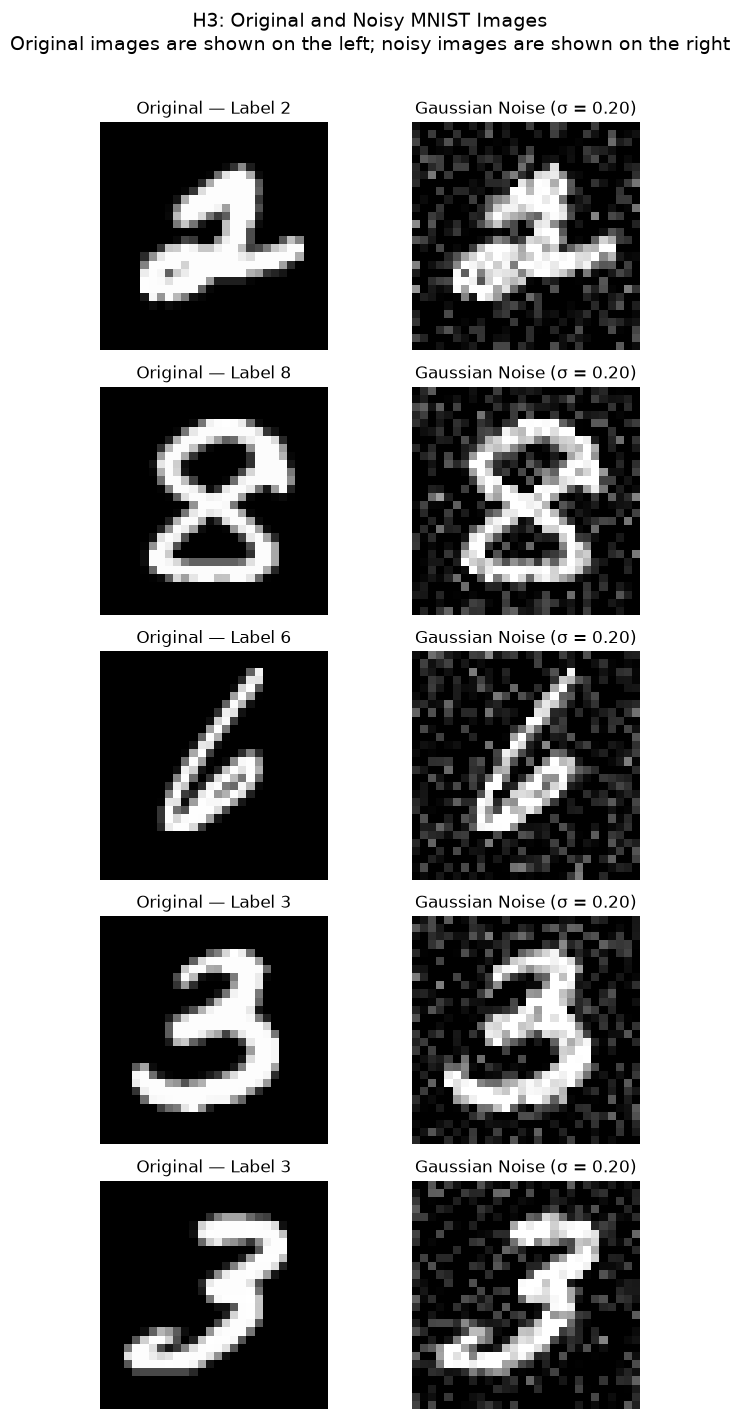

In [11]:
OH3_EXAMPLE_NOISE_STD = 0.20
OH3_NUMBER_OF_EXAMPLES = 5


oh3_example_rng = np.random.default_rng(
    SPLIT_SEED
)

oh3_example_indices = oh3_example_rng.choice(
    X_val.shape[0],
    size=OH3_NUMBER_OF_EXAMPLES,
    replace=False
)


oh3_example_originals = X_val[
    oh3_example_indices
]

oh3_example_noise = (
    oh3_validation_standard_noise[
        oh3_example_indices
    ]
)

oh3_example_noisy = (
    oh3_add_gaussian_noise(
        oh3_example_originals,
        oh3_example_noise,
        OH3_EXAMPLE_NOISE_STD
    )
)


fig, axes = plt.subplots(
    nrows=OH3_NUMBER_OF_EXAMPLES,
    ncols=2,
    figsize=(7, 14)
)


for row_index, example_index in enumerate(
    oh3_example_indices
):
    true_label = y_val[
        example_index
    ]

    axes[row_index, 0].imshow(
        oh3_example_originals[
            row_index
        ].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row_index, 0].set_title(
        f"Original — Label {true_label}"
    )

    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(
        oh3_example_noisy[
            row_index
        ].reshape(28, 28),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row_index, 1].set_title(
        "Gaussian Noise "
        f"(σ = {OH3_EXAMPLE_NOISE_STD:.2f})"
    )

    axes[row_index, 1].axis("off")


fig.suptitle(
    "H3: Original and Noisy MNIST Images\n"
    "Original images are shown on the left; "
    "noisy images are shown on the right",
    fontsize=14,
    y=1.01
)

plt.tight_layout()


oh3_example_figure_path = (
    OH3_OUTPUT_DIR
    / "h3_original_vs_noisy_examples.png"
)

fig.savefig(
    oh3_example_figure_path,
    dpi=300,
    bbox_inches="tight"
)

print("Saved:", oh3_example_figure_path)

plt.show()
plt.close(fig)

In [12]:
def oh3_evaluate_noise_levels(
    X,
    y,
    dataset_name,
    models,
    noise_levels,
    standard_noise
):
    rows = []

    for noise_std in noise_levels:

        noisy_X = oh3_add_gaussian_noise(
            X,
            standard_noise,
            noise_std
        )

        for seed, model_information in (
            models.items()
        ):
            loss, accuracy = evaluate_model(
                noisy_X,
                y,
                model_information[
                    "parameters"
                ],
                model_information[
                    "activation"
                ]
            )

            rows.append({
                "dataset": dataset_name,
                "seed": seed,
                "noise_std": noise_std,
                "loss": loss,
                "accuracy": accuracy
            })

            print(
                f"{dataset_name} | "
                f"seed={seed} | "
                f"noise σ={noise_std:.2f} | "
                f"loss={loss:.4f} | "
                f"accuracy="
                f"{100 * accuracy:.2f}%"
            )

    return pd.DataFrame(rows)

In [13]:
oh3_validation_raw_df = (
    oh3_evaluate_noise_levels(
        X=X_val,
        y=y_val,
        dataset_name="validation",
        models=oh3_models,
        noise_levels=OH3_NOISE_LEVELS,
        standard_noise=(
            oh3_validation_standard_noise
        )
    )
)


expected_evaluations = (
    len(OH3_NOISE_LEVELS)
    * len(OH3_SEEDS)
)

assert len(
    oh3_validation_raw_df
) == expected_evaluations


print(
    "\nNumber of validation evaluations:",
    len(oh3_validation_raw_df)
)

display(oh3_validation_raw_df)

validation | seed=654571 | noise σ=0.00 | loss=0.0726 | accuracy=98.00%
validation | seed=89250 | noise σ=0.00 | loss=0.0759 | accuracy=97.95%
validation | seed=773955 | noise σ=0.00 | loss=0.0743 | accuracy=97.89%
validation | seed=654571 | noise σ=0.05 | loss=0.0736 | accuracy=97.84%
validation | seed=89250 | noise σ=0.05 | loss=0.0789 | accuracy=97.86%
validation | seed=773955 | noise σ=0.05 | loss=0.0757 | accuracy=97.77%
validation | seed=654571 | noise σ=0.10 | loss=0.0896 | accuracy=97.24%
validation | seed=89250 | noise σ=0.10 | loss=0.0964 | accuracy=97.26%
validation | seed=773955 | noise σ=0.10 | loss=0.0915 | accuracy=97.37%
validation | seed=654571 | noise σ=0.20 | loss=0.2558 | accuracy=91.28%
validation | seed=89250 | noise σ=0.20 | loss=0.2717 | accuracy=90.52%
validation | seed=773955 | noise σ=0.20 | loss=0.2544 | accuracy=91.34%
validation | seed=654571 | noise σ=0.30 | loss=0.8588 | accuracy=75.20%
validation | seed=89250 | noise σ=0.30 | loss=0.8663 | accuracy=75.5

,dataset,seed,noise_std,loss,accuracy
0,validation,654571,0.00,0.072569,0.9800
1,validation,89250,0.00,0.075936,0.9795
2,validation,773955,0.00,0.074269,0.9789
3,validation,654571,0.05,0.073609,0.9784
4,validation,89250,0.05,0.078944,0.9786
5,validation,773955,0.05,0.075721,0.9777
6,validation,654571,0.10,0.089648,0.9724
7,validation,89250,0.10,0.096350,0.9726
8,validation,773955,0.10,0.091483,0.9737
9,validation,654571,0.20,0.255774,0.9128


In [14]:
clean_validation_by_seed = (
    oh3_validation_raw_df[
        oh3_validation_raw_df[
            "noise_std"
        ] == 0.0
    ]
    .set_index("seed")
)


oh3_validation_raw_df[
    "accuracy_drop"
] = oh3_validation_raw_df.apply(
    lambda row: (
        clean_validation_by_seed.loc[
            row["seed"],
            "accuracy"
        ]
        - row["accuracy"]
    ),
    axis=1
)


oh3_validation_raw_df[
    "loss_increase"
] = oh3_validation_raw_df.apply(
    lambda row: (
        row["loss"]
        - clean_validation_by_seed.loc[
            row["seed"],
            "loss"
        ]
    ),
    axis=1
)

In [15]:
oh3_validation_summary_df = (
    oh3_validation_raw_df
    .groupby(
        "noise_std",
        as_index=False
    )
    .agg(
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        accuracy_mean=(
            "accuracy",
            "mean"
        ),
        accuracy_std=(
            "accuracy",
            "std"
        ),
        accuracy_drop_mean=(
            "accuracy_drop",
            "mean"
        ),
        accuracy_drop_std=(
            "accuracy_drop",
            "std"
        ),
        loss_increase_mean=(
            "loss_increase",
            "mean"
        ),
        loss_increase_std=(
            "loss_increase",
            "std"
        )
    )
    .sort_values("noise_std")
)

In [16]:
oh3_validation_display_rows = []


for _, row in (
    oh3_validation_summary_df.iterrows()
):

    oh3_validation_display_rows.append({
        "Gaussian Noise σ": (
            f"{row['noise_std']:.2f}"
        ),
        "Validation Accuracy": (
            f"{100 * row['accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['accuracy_std']:.2f}%"
        ),
        "Accuracy Drop": (
            f"{100 * row['accuracy_drop_mean']:.2f} "
            f"± "
            f"{100 * row['accuracy_drop_std']:.2f} "
            "points"
        ),
        "Validation Loss": (
            f"{row['loss_mean']:.4f} "
            f"± {row['loss_std']:.4f}"
        ),
        "Loss Increase": (
            f"{row['loss_increase_mean']:.4f} "
            f"± "
            f"{row['loss_increase_std']:.4f}"
        )
    })


oh3_validation_display_df = pd.DataFrame(
    oh3_validation_display_rows
)


print(
    "H3 VALIDATION RESULTS: "
    "MEAN ± SAMPLE STANDARD DEVIATION"
)

display(oh3_validation_display_df)

H3 VALIDATION RESULTS: MEAN ± SAMPLE STANDARD DEVIATION


,Gaussian Noise σ,Validation Accuracy,Accuracy Drop,Validation Loss,Loss Increase
0,0.00,97.95% ± 0.06%,0.00 ± 0.00 points,0.0743 ± 0.0017,0.0000 ± 0.0000
1,0.05,97.82% ± 0.05%,0.12 ± 0.04 points,0.0761 ± 0.0027,0.0018 ± 0.0010
2,0.10,97.29% ± 0.07%,0.66 ± 0.12 points,0.0925 ± 0.0035,0.0182 ± 0.0019
3,0.20,91.05% ± 0.46%,6.90 ± 0.47 points,0.2606 ± 0.0096,0.1864 ± 0.0083
4,0.30,76.12% ± 1.29%,21.82 ± 1.34 points,0.8428 ± 0.0345,0.7685 ± 0.0344
5,0.40,61.38% ± 2.07%,36.57 ± 2.12 points,1.8426 ± 0.1011,1.7683 ± 0.1014
6,0.50,48.60% ± 2.53%,49.35 ± 2.58 points,3.0318 ± 0.1670,2.9575 ± 0.1673
7,0.60,38.84% ± 2.60%,59.11 ± 2.65 points,4.1903 ± 0.2089,4.1161 ± 0.2090
8,0.70,32.04% ± 1.95%,65.91 ± 2.01 points,5.2063 ± 0.2260,5.1321 ± 0.2257
9,0.80,27.38% ± 1.69%,70.57 ± 1.75 points,6.0631 ± 0.2350,5.9888 ± 0.2345


In [17]:
def oh3_plot_noise_results(
    summary_df,
    dataset_label,
    output_directory
):
    noise_levels = summary_df[
        "noise_std"
    ].to_numpy()

    accuracy_means = summary_df[
        "accuracy_mean"
    ].to_numpy()

    accuracy_stds = summary_df[
        "accuracy_std"
    ].to_numpy()

    loss_means = summary_df[
        "loss_mean"
    ].to_numpy()

    loss_stds = summary_df[
        "loss_std"
    ].to_numpy()


    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.5)
    )


    axes[0].errorbar(
        noise_levels,
        accuracy_means,
        yerr=accuracy_stds,
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=5,
        color="tab:blue"
    )

    axes[0].set_title(
        f"{dataset_label} Accuracy"
    )

    axes[0].set_xlabel(
        "Gaussian Noise Standard Deviation (σ)"
    )

    axes[0].set_ylabel("Accuracy")

    axes[0].yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )

    axes[0].set_xticks(
        noise_levels
    )

    axes[0].grid(alpha=0.3)


    axes[1].errorbar(
        noise_levels,
        loss_means,
        yerr=loss_stds,
        marker="o",
        markersize=7,
        linewidth=2,
        capsize=5,
        color="tab:red"
    )

    axes[1].set_title(
        f"{dataset_label} Loss"
    )

    axes[1].set_xlabel(
        "Gaussian Noise Standard Deviation (σ)"
    )

    axes[1].set_ylabel(
        "Cross-Entropy Loss"
    )

    axes[1].set_xticks(
        noise_levels
    )

    axes[1].set_ylim(bottom=0)
    axes[1].grid(alpha=0.3)


    fig.suptitle(
        "H3: Effect of Gaussian Pixel Noise\n"
        "Points show the mean of 3 seeds; "
        "error bars show ±1 sample standard deviation",
        fontsize=14
    )

    plt.tight_layout()


    safe_dataset_name = (
        dataset_label.lower()
    )

    png_path = (
        output_directory
        / (
            f"h3_{safe_dataset_name}_"
            "gaussian_noise.png"
        )
    )

    pdf_path = (
        output_directory
        / (
            f"h3_{safe_dataset_name}_"
            "gaussian_noise.pdf"
        )
    )


    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )


    print("Saved:", png_path)
    print("Saved:", pdf_path)

    plt.show()
    plt.close(fig)

Saved: output/hypotheses/h3_gaussian_noise/h3_validation_gaussian_noise.png
Saved: output/hypotheses/h3_gaussian_noise/h3_validation_gaussian_noise.pdf


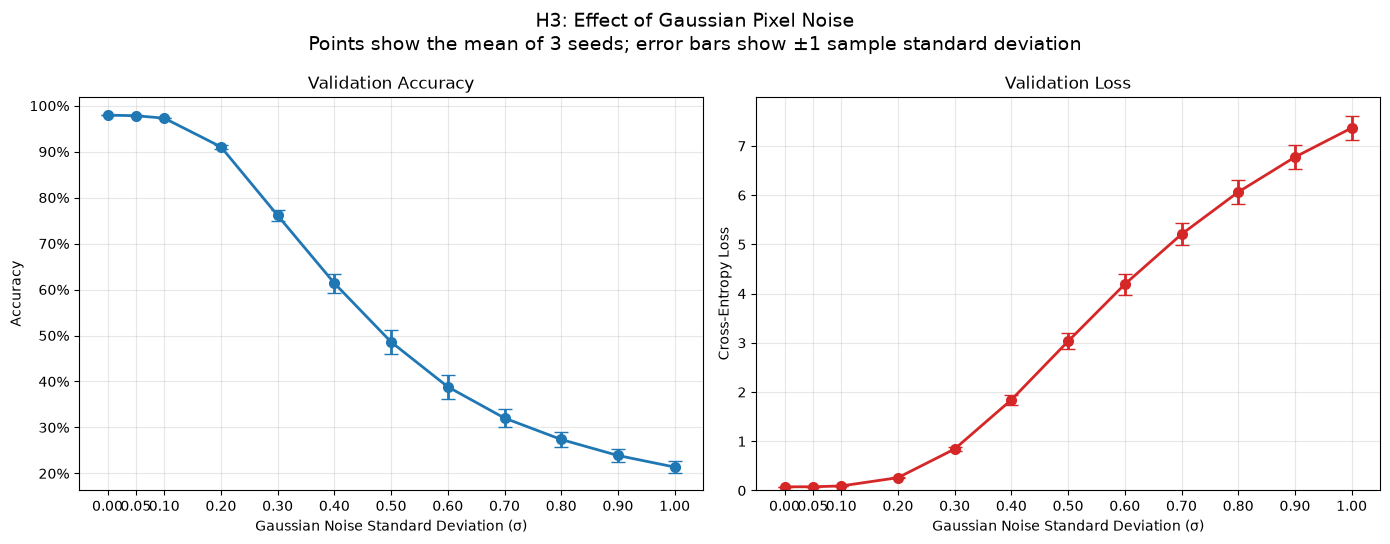

In [18]:
oh3_plot_noise_results(
    summary_df=oh3_validation_summary_df,
    dataset_label="Validation",
    output_directory=OH3_OUTPUT_DIR
)

In [19]:
ordered_validation_results = (
    oh3_validation_summary_df
    .sort_values("noise_std")
)


validation_accuracies = (
    ordered_validation_results[
        "accuracy_mean"
    ].to_numpy()
)

validation_losses = (
    ordered_validation_results[
        "loss_mean"
    ].to_numpy()
)


accuracy_decreases_monotonically = (
    np.all(
        np.diff(
            validation_accuracies
        ) <= 0
    )
)

loss_increases_monotonically = (
    np.all(
        np.diff(
            validation_losses
        ) >= 0
    )
)


clean_accuracy = (
    validation_accuracies[0]
)

highest_noise_accuracy = (
    validation_accuracies[-1]
)

total_accuracy_drop = (
    clean_accuracy
    - highest_noise_accuracy
)


print(
    "Validation accuracy decreases "
    "monotonically:",
    bool(
        accuracy_decreases_monotonically
    )
)

print(
    "Validation loss increases "
    "monotonically:",
    bool(
        loss_increases_monotonically
    )
)

print(
    "Accuracy drop from σ=0.00 "
    "to σ=1.00:",
    f"{100 * total_accuracy_drop:.2f} "
    "percentage points"
)

Validation accuracy decreases monotonically: True
Validation loss increases monotonically: True
Accuracy drop from σ=0.00 to σ=1.00: 76.57 percentage points


In [20]:
oh3_validation_raw_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_validation_results_by_seed.csv",
    index=False
)

oh3_validation_summary_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_validation_summary_numeric.csv",
    index=False
)

oh3_validation_display_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_validation_summary_formatted.csv",
    index=False
)

oh3_checkpoint_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_model_checkpoints.csv",
    index=False
)

print("Validation results saved.")

Validation results saved.


test | seed=654571 | noise σ=0.00 | loss=0.0716 | accuracy=97.81%
test | seed=89250 | noise σ=0.00 | loss=0.0716 | accuracy=97.89%
test | seed=773955 | noise σ=0.00 | loss=0.0719 | accuracy=97.84%
test | seed=654571 | noise σ=0.05 | loss=0.0749 | accuracy=97.67%
test | seed=89250 | noise σ=0.05 | loss=0.0767 | accuracy=97.68%
test | seed=773955 | noise σ=0.05 | loss=0.0757 | accuracy=97.75%
test | seed=654571 | noise σ=0.10 | loss=0.0911 | accuracy=97.16%
test | seed=89250 | noise σ=0.10 | loss=0.0950 | accuracy=97.19%
test | seed=773955 | noise σ=0.10 | loss=0.0916 | accuracy=97.20%
test | seed=654571 | noise σ=0.20 | loss=0.2428 | accuracy=91.90%
test | seed=89250 | noise σ=0.20 | loss=0.2639 | accuracy=90.84%
test | seed=773955 | noise σ=0.20 | loss=0.2501 | accuracy=91.29%
test | seed=654571 | noise σ=0.30 | loss=0.8154 | accuracy=76.23%
test | seed=89250 | noise σ=0.30 | loss=0.8352 | accuracy=76.41%
test | seed=773955 | noise σ=0.30 | loss=0.7764 | accuracy=78.68%
test | seed=654

,Gaussian Noise σ,Test Accuracy,Accuracy Drop,Test Loss
0,0.00,97.85% ± 0.04%,0.00 ± 0.00 points,0.0717 ± 0.0001
1,0.05,97.70% ± 0.04%,0.15 ± 0.06 points,0.0758 ± 0.0009
2,0.10,97.18% ± 0.02%,0.66 ± 0.03 points,0.0926 ± 0.0021
3,0.20,91.34% ± 0.53%,6.50 ± 0.57 points,0.2523 ± 0.0107
4,0.30,77.11% ± 1.37%,20.74 ± 1.37 points,0.8090 ± 0.0299
5,0.40,62.06% ± 2.17%,35.78 ± 2.16 points,1.7833 ± 0.0923
6,0.50,49.02% ± 2.45%,48.83 ± 2.44 points,2.9656 ± 0.1561
7,0.60,39.43% ± 2.29%,58.41 ± 2.29 points,4.1239 ± 0.1971
8,0.70,32.43% ± 2.17%,65.42 ± 2.16 points,5.1440 ± 0.2181
9,0.80,27.67% ± 1.84%,70.17 ± 1.83 points,6.0054 ± 0.2324


Saved: output/hypotheses/h3_gaussian_noise/h3_test_gaussian_noise.png
Saved: output/hypotheses/h3_gaussian_noise/h3_test_gaussian_noise.pdf


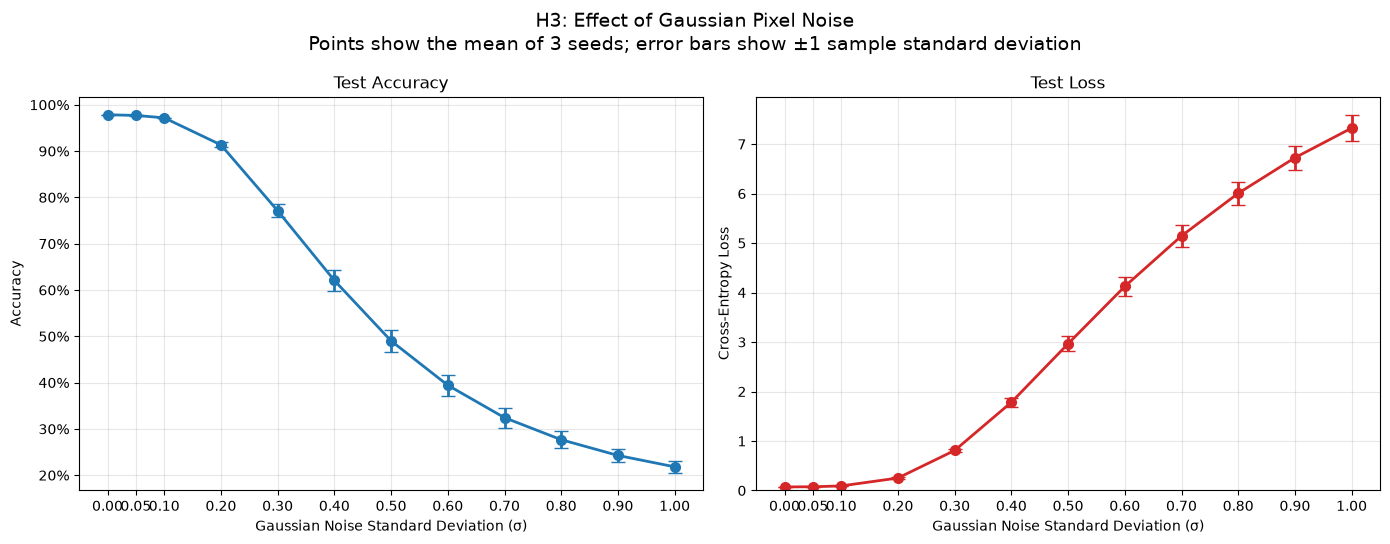


Saved H3 files:
- output/hypotheses/h3_gaussian_noise/h3_model_checkpoints.csv
- output/hypotheses/h3_gaussian_noise/h3_original_vs_noisy_examples.png
- output/hypotheses/h3_gaussian_noise/h3_test_gaussian_noise.pdf
- output/hypotheses/h3_gaussian_noise/h3_test_gaussian_noise.png
- output/hypotheses/h3_gaussian_noise/h3_test_results_by_seed.csv
- output/hypotheses/h3_gaussian_noise/h3_test_summary_formatted.csv
- output/hypotheses/h3_gaussian_noise/h3_test_summary_numeric.csv
- output/hypotheses/h3_gaussian_noise/h3_validation_gaussian_noise.pdf
- output/hypotheses/h3_gaussian_noise/h3_validation_gaussian_noise.png
- output/hypotheses/h3_gaussian_noise/h3_validation_results_by_seed.csv
- output/hypotheses/h3_gaussian_noise/h3_validation_summary_formatted.csv
- output/hypotheses/h3_gaussian_noise/h3_validation_summary_numeric.csv


In [21]:
## on test set analysis

oh3_test_standard_noise = (
    oh3_create_standard_noise(
        X_test,
        OH3_TEST_NOISE_SEED
    )
)


oh3_test_raw_df = (
    oh3_evaluate_noise_levels(
        X=X_test,
        y=y_test,
        dataset_name="test",
        models=oh3_models,
        noise_levels=OH3_NOISE_LEVELS,
        standard_noise=(
            oh3_test_standard_noise
        )
    )
)


clean_test_by_seed = (
    oh3_test_raw_df[
        oh3_test_raw_df[
            "noise_std"
        ] == 0.0
    ]
    .set_index("seed")
)


oh3_test_raw_df[
    "accuracy_drop"
] = oh3_test_raw_df.apply(
    lambda row: (
        clean_test_by_seed.loc[
            row["seed"],
            "accuracy"
        ]
        - row["accuracy"]
    ),
    axis=1
)


oh3_test_raw_df[
    "loss_increase"
] = oh3_test_raw_df.apply(
    lambda row: (
        row["loss"]
        - clean_test_by_seed.loc[
            row["seed"],
            "loss"
        ]
    ),
    axis=1
)


oh3_test_summary_df = (
    oh3_test_raw_df
    .groupby(
        "noise_std",
        as_index=False
    )
    .agg(
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
        accuracy_mean=(
            "accuracy",
            "mean"
        ),
        accuracy_std=(
            "accuracy",
            "std"
        ),
        accuracy_drop_mean=(
            "accuracy_drop",
            "mean"
        ),
        accuracy_drop_std=(
            "accuracy_drop",
            "std"
        ),
        loss_increase_mean=(
            "loss_increase",
            "mean"
        ),
        loss_increase_std=(
            "loss_increase",
            "std"
        )
    )
    .sort_values("noise_std")
)


oh3_test_display_rows = []


for _, row in (
    oh3_test_summary_df.iterrows()
):

    oh3_test_display_rows.append({
        "Gaussian Noise σ": (
            f"{row['noise_std']:.2f}"
        ),
        "Test Accuracy": (
            f"{100 * row['accuracy_mean']:.2f}% "
            f"± "
            f"{100 * row['accuracy_std']:.2f}%"
        ),
        "Accuracy Drop": (
            f"{100 * row['accuracy_drop_mean']:.2f} "
            f"± "
            f"{100 * row['accuracy_drop_std']:.2f} "
            "points"
        ),
        "Test Loss": (
            f"{row['loss_mean']:.4f} "
            f"± {row['loss_std']:.4f}"
        )
    })


oh3_test_display_df = pd.DataFrame(
    oh3_test_display_rows
)


print(
    "H3 FINAL TEST RESULTS: "
    "MEAN ± SAMPLE STANDARD DEVIATION"
)

display(oh3_test_display_df)


oh3_plot_noise_results(
    summary_df=oh3_test_summary_df,
    dataset_label="Test",
    output_directory=OH3_OUTPUT_DIR
)


oh3_test_raw_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_test_results_by_seed.csv",
    index=False
)

oh3_test_summary_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_test_summary_numeric.csv",
    index=False
)

oh3_test_display_df.to_csv(
    OH3_OUTPUT_DIR
    / "h3_test_summary_formatted.csv",
    index=False
)


print("\nSaved H3 files:")

for saved_file in sorted(
    OH3_OUTPUT_DIR.iterdir()
):
    print("-", saved_file)